### LDA Topic Modelling on Negative Reviews

Latent Dirichlet Allocation (LDA) is applied to negative reviews to uncover hidden complaint themes.

The goal is to identify the most common fintech complaint categories such as:
- fraud complaints
- failed transactions
- hidden charges
- customer support issues

LDA is an unsupervised machine learning technique that groups frequently co-occurring words into interpretable topics.

In [1]:
import pandas as pd
import gensim
import gensim.corpora as corpora
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
cleaned_df = pd.read_csv(
    'cleaned_data.csv',
    keep_default_na=False
)

Negative reviews : 10,971

TOP WORDS PER TOPIC — update TOPIC_LABELS based on these

  Topic 0: ['very', 'bad', 'good', 'app', 'hai', 'loan', 'poor', 'se', 'fake', 'nice']
  Topic 1: ['the', 'app', 'to', 'is', 'this', 'it', 'and', 'you', 'use', 'a']
  Topic 2: ['i', 'to', 'the', 'it', 'my', 'app', 'not', 'and', 'in', 'is']
  Topic 3: ['loan', 'i', 'and', 'you', 'my', 'a', 'app', 'this', 'the', 'they']


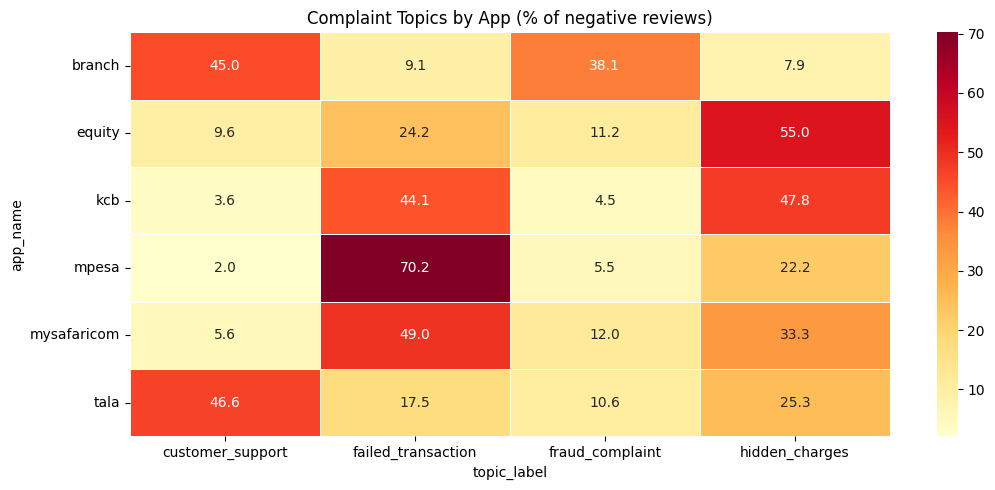


SAMPLE REVIEWS PER TOPIC

FRAUD_COMPLAINT:
  slow,,,too slow

FAILED_TRANSACTION:
  this is the stupidest app ever from saf. the worst

HIDDEN_CHARGES:
  The app still has issues on OTP, because I haven't received my OTP to login. I tried everything they recommended, but the issue hasn't been resolved. 

CUSTOMER_SUPPORT:
  another terrible app by a company that makes billions each year.



In [10]:


def run_lda(df, n_topics=4):
    """
    Runs LDA topic modelling on negative reviews.
    Identifies: fraud, failed transactions, hidden charges, customer support.
    """

    # ── Step 1: Filter negative reviews ───────────────────
    neg = df[
        (df['sentiment_label'] == 'negative') &
        (df['cleaned_text'].notna()) &
        (df['cleaned_text'].str.strip() != '')
    ].copy()
    print(f'Negative reviews : {len(neg):,}')

    # ── Step 2: Prepare corpus ────────────────────────────
    texts     = [text.split() for text in neg['cleaned_text']]
    dictionary = corpora.Dictionary(texts)
    dictionary.filter_extremes(no_below=5, no_above=0.90)
    corpus    = [dictionary.doc2bow(text) for text in texts]

    # ── Step 3: Train LDA ─────────────────────────────────
    lda = gensim.models.LdaModel(
        corpus       = corpus,
        id2word      = dictionary,
        num_topics   = n_topics,
        random_state = 42,
        passes       = 20,
        alpha        = 'auto',
    )

    # ── Step 4: Print top words per topic ─────────────────
    print('\nTOP WORDS PER TOPIC — update TOPIC_LABELS based on these\n')
    for i in range(n_topics):
        words = [w for w, _ in lda.show_topic(i, topn=10)]
        print(f'  Topic {i}: {words}')

    # ── Step 5: Label topics — UPDATE THIS after seeing words above
    TOPIC_LABELS = {
        0: 'fraud_complaint',
        1: 'failed_transaction',
        2: 'hidden_charges',
        3: 'customer_support',
    }

    # ── Step 6: Assign dominant topic to each review ──────
    def dominant_topic(bow):
        topics = lda.get_document_topics(bow)
        return max(topics, key=lambda x: x[1])[0] if topics else -1

    neg_corpus         = [dictionary.doc2bow(t) for t in texts]
    neg['topic_id']    = [dominant_topic(b) for b in neg_corpus]
    neg['topic_label'] = neg['topic_id'].map(TOPIC_LABELS)

    # ── Step 7: Heatmap — topic distribution by app ───────
    pivot = (neg.groupby(['app_name', 'topic_label'])
               .size()
               .unstack(fill_value=0))
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

    plt.figure(figsize=(11, 5))
    sns.heatmap(pivot_pct, annot=True, fmt='.1f',
                cmap='YlOrRd', linewidths=0.5)
    plt.title('Complaint Topics by App (% of negative reviews)')
    plt.tight_layout()
    plt.show()

    # ── Step 8: Print sample review per topic ─────────────
    print('\nSAMPLE REVIEWS PER TOPIC\n')
    for label in TOPIC_LABELS.values():
        sample = neg[neg['topic_label'] == label]['content'].iloc[0]
        print(f'{label.upper()}:')
        print(f'  {sample[:150]}')
        print()
    return lda, corpus, dictionary
lda_model, corpus, id2word = run_lda(cleaned_df, n_topics=4)

    


# ── LDA Findings and Interpretation ──────────────────────


LDA topic modelling was applied to 10,971 negative reviews to identify latent complaint themes. The model identified 4 topics however the topic words and sample reviews suggest significant overlap between complaint categories.

This is consistent with the nature of the data — Kenyan fintech users tend to write short, emotionally charged reviews that combine multiple complaints in one sentence (e.g. "bad app,slow and stole my money, customer service useless").

This finding has an important implication for modeling: because complaints are not cleanly separable by topic, a keyword-based complaint classifier (complaint_label column) is more reliable than unsupervised LDA for this dataset.The keyword classifier is used as the complaint feature in the XGBoost model.

LDA does however confirm that negative reviews cluster around app performance, financial transactions, and service quality — validating our three complaint categories.
